In [35]:
import numpy as np
from drifter import DroguedDrifter
import matplotlib.pyplot as plt

In [36]:
x = np.linspace(0, 1000, 100)
y = np.linspace(0, 1000, 100)
z = np.linspace(0, 5, 20)

X, Y, Z = np.meshgrid(x, y, z)

In [37]:
def get_uv(t, z_d, y_b, x_b, ds_subset=None):
    u0 = 0.5
    z_gb = 0
    z_gd = z_d / 5.0

    # Buoy (everything 0)
    psi_dx_b = (
        (1 / 3)
        * np.pi
        * z_gb
        * np.cos(2 * np.pi * y_b / 200)
        * np.sin(2 * np.pi * x_b / 200)
    )
    psi_dy_b = (
        (1 / 3)
        * np.pi
        * z_gb
        * np.sin(2 * np.pi * y_b / 200)
        * np.cos(2 * np.pi * x_b / 200)
    )

    # Drogue
    psi_dx_d = (
        (1 / 3)
        * np.pi
        * z_gd
        * np.cos(2 * np.pi * y_b / 200)
        * np.sin(2 * np.pi * x_b / 200)
    )
    psi_dy_d = (
        (1 / 3)
        * np.pi
        * z_gd
        * np.sin(2 * np.pi * y_b / 200)
        * np.cos(2 * np.pi * x_b / 200)
    )

    U_b = u0
    V_b = 0.0
    U_d = psi_dy_d
    V_d = -u0 - psi_dx_d

    return U_b, V_b, U_d, V_d

drifter = DroguedDrifter(get_uv = get_uv)
t_eval = np.linspace(0, 60, 60)
t_span = (0, 60)
y0 = np.array([100.0, 200.0, 3*np.pi/4, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=float)
sol = drifter.get_full_solution(t_span, y0, t_eval = t_eval)

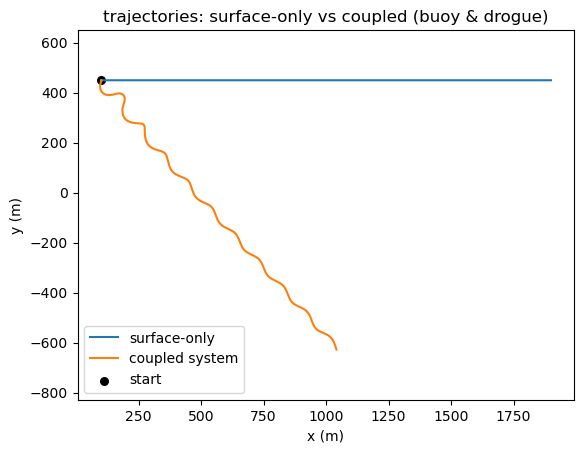

In [39]:
def surface_only(x0, y0, U0, V0, T, dt):
    t = np.arange(0.0, T + dt, dt)
    x = x0 + U0 * t
    y = y0 + V0 * t
    return t, x, y


def coupled_traj(drifter, y0, T=3600.0, dt=1.0, atol=1e-3, rtol=1e-3):
    t_eval = np.arange(0.0, T + dt, dt)
    sol = drifter.get_full_solution((0.0, T), y0, t_eval=t_eval, atol=atol, rtol=rtol)

    x_b = sol.y[0, :]
    y_b = sol.y[1, :]

    return sol.t, x_b, y_b, sol


drifter = DroguedDrifter(get_uv=get_uv)
y0 = np.array([100.0, 450.0, 3 * np.pi / 4, 0.0, 0, 0, 0, 0])

T = 3600.0
dt = 1.0

t_s, x_s, y_s = surface_only(y0[0], y0[1], U0=0.5, V0=0, T=T, dt=dt)

# Coupled
t_c, x_b, y_b, sol = coupled_traj(drifter, y0, T=T, dt=dt)

# Plot
plt.figure()
plt.plot(x_s, y_s, label="surface-only")
plt.plot(x_b, y_b, label="coupled system")
plt.scatter([y0[0]], [y0[1]], s=30, label="start", color="k")
plt.axis("equal")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.title("trajectories: surface-only vs coupled (buoy & drogue)")
plt.show()